(a) Consider a GPT-2 XL-sized model using our assignment architecture, which has the following
configuration:
vocab_size:  50,257
context_length:  1,024
num_layers:  48
d_model:  1,600
num_heads:  25
d_ff:  4,288 (the nearest multiple of 64 to 8/3 × 1, 600)
Suppose we constructed our model using this configuration. How many trainable parameters
would our model have? Assuming each parameter is represented using single-precision floating
point, how much memory is required to just load this model?
Deliverable: A one-to-two sentence response.

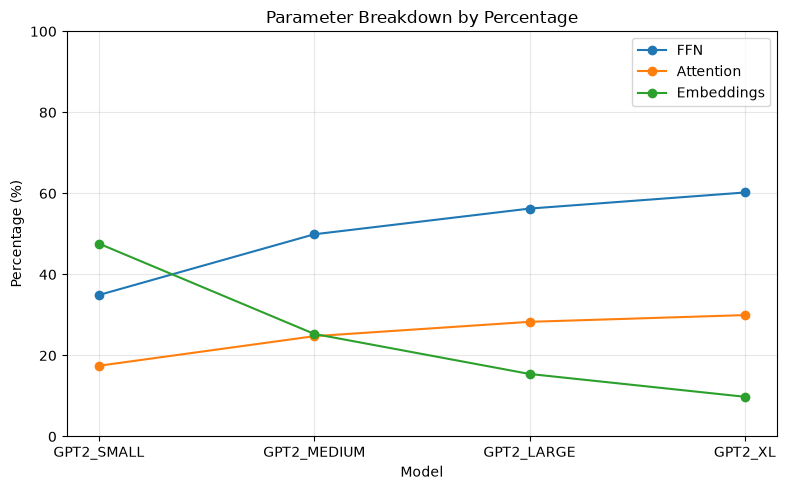

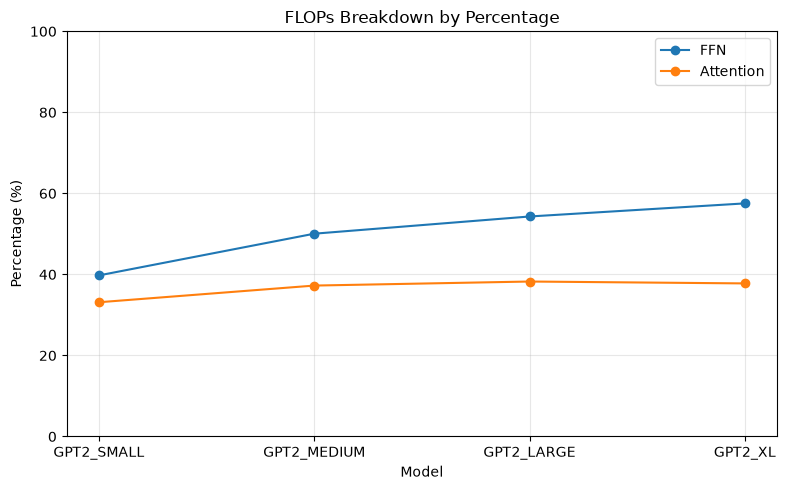

In [ ]:
import matplotlib.pyplot as plt

from modules import calc_params_flops


def get_d_ff(D: int):
    return round((8 / 3 * D) / 64) * 64


configs = {
    "GPT2_SMALL": {
        "L": 12,
        "D": 768,
        "H": 12,
        "D_": get_d_ff(768),
    },
    "GPT2_MEDIUM": {
        "L": 24,
        "D": 1024,
        "H": 16,
        "D_": get_d_ff(1024),
    },
    "GPT2_LARGE": {
        "L": 36,
        "D": 1280,
        "H": 20,
        "D_": get_d_ff(1280),
    },
    "GPT2_XL": {
        "L": 48,
        "D": 1600,
        "H": 25,
        "D_": get_d_ff(1600),
    },
}

V = 50257
S = 1024


def collect_percentages():
    param_percentages = {}
    flop_percentages = {}

    for model_name, config in configs.items():
        params, flops, full_params, full_flops = calc_params_flops(V, S, **config)

        for part_name, value in full_params.items():
            param_percentages.setdefault(part_name, [])
            param_percentages[part_name].append(value / params * 100)

        for part_name, value in full_flops.items():
            flop_percentages.setdefault(part_name, [])
            flop_percentages[part_name].append(value / flops * 100)

    return param_percentages, flop_percentages


def plot_percent_line_chart(data: dict, title: str):
    model_names = list(configs.keys())

    plt.figure(figsize=(8, 5))

    for part_name, percentages in data.items():
        plt.plot(model_names, percentages, marker="o", label=part_name)

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel("Percentage (%)")
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


param_percentages, flop_percentages = collect_percentages()

plot_percent_line_chart(param_percentages, "Parameter Breakdown by Percentage")
plot_percent_line_chart(flop_percentages, "FLOPs Breakdown by Percentage")

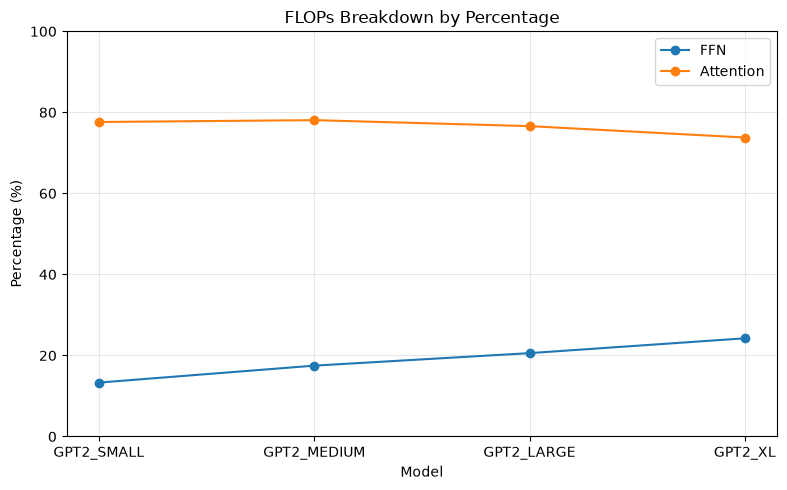

In [10]:

S = 16384
param_percentages, flop_percentages = collect_percentages()

plot_percent_line_chart(flop_percentages, "FLOPs Breakdown by Percentage")

In [ ]:
import torch
from modules import *
weights = torch.nn.Parameter(5 * torch.randn((10, 10)))
opt = SGD([weights], lr=1)
for t in range(100):
    opt.zero_grad() # Reset the gradients for all learnable parameters.
    loss = (weights**2).mean() # Compute a scalar loss value.
    print(loss.cpu().item())
    loss.backward() # Run backward pass, which computes gradients.
    opt.step() # R

NameError: name 'SGD' is not defined